Detecting Corona from cought. Database taken form Virufy open source folder on internet.
@SabinaG


In [ ]:
#imports

import pandas as pd
import numpy as np
import os

In [ ]:
#form folders and upload original (mp3) files into MP3 folder

if not os.path.exists('CORONA'):
       os.mkdir ('CORONA') #making parent folder for all files
if not os.path.exists('CORONA/MP3'):
       os.mkdir ('CORONA/MP3')


#importing files form PC to Colab mp3 folder
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
    if filename.endswith('.mp3'):
        with open(filename, 'wb') as f:
            f.write(uploaded[filename])
        !mv {filename} CORONA/MP3/

In [ ]:
#converting mp3 files into wav files:
#reads mp3 files form the folder, convert into wav files and save into another folder

!pip install pydub
from pydub import AudioSegment

if not os.path.exists('CORONA/WAV'):
       os.mkdir ('CORONA/WAV')

mp3_folder = 'CORONA/MP3' #source MP3 audio folder
wav_folder = 'CORONA/WAV' #destination WAV audio folder

for file in os.listdir(mp3_folder):
      if file.endswith('.mp3'):
        mp3_file = os.path.join(mp3_folder, file)
        wav_file = os.path.join(wav_folder, file.replace('.mp3', '.wav'))
        cought = AudioSegment.from_mp3(mp3_file)
        cought.export(wav_file, format='wav')

In [ ]:
#renaming files' names cuting unnecessary part of the name leaving only pos/neg part
# ?should I?

if not os.path.exists('CORONA/WAV_RENAMED'):
       os.mkdir ('CORONA/WAV_RENAMED')

wav_folder = 'CORONA/WAV'
renamed_folder = 'CORONA/WAV_RENAMED'

for file in os.listdir(wav_folder):
    if file.endswith('.wav'):
        parts = file.split('-')
        new_file = '-'.join([parts[0], parts[-1]])
        os.rename(os.path.join(wav_folder, file), os.path.join(renamed_folder, new_file))


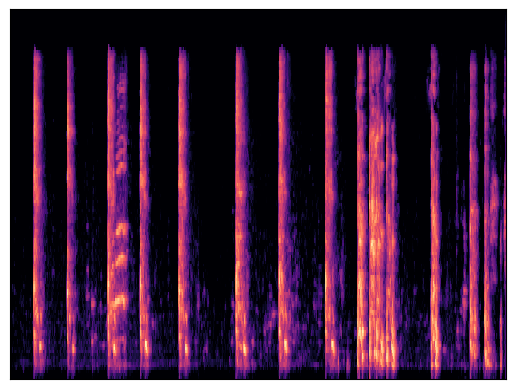

In [ ]:
#specrograms generating

import librosa
import matplotlib.pyplot as plt

if not os.path.exists('CORONA/SPECTROS'):
       os.mkdir ('CORONA/SPECTROS')

audios = 'CORONA/WAV'
spectros = 'CORONA/SPECTROS'

# Loop through all files in the WAV folder
for filename in os.listdir(audios):
    if filename.endswith(".wav"):
        # Load the audio file
        audio_path = os.path.join(audios, filename)
        y, sr = librosa.load(audio_path)

        # Generate the spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr)

        # Save the spectrogram to file
        spect_filename = os.path.splitext(filename)[0] + ".png"
        spect_path = os.path.join(spectros, spect_filename)
        librosa.display.specshow(librosa.power_to_db(S, ref=np.max))
        plt.savefig(spect_path)

In [ ]:
!zip -r /content/CORONA/SPECTROS.zip /content/CORONA/SPECTROS

  adding: content/CORONA/SPECTROS/ (stored 0%)
  adding: content/CORONA/SPECTROS/neg-0421-083-cough-m-53.png (deflated 3%)
  adding: content/CORONA/SPECTROS/neg-0421-090-cough-f-17.png (deflated 3%)
  adding: content/CORONA/SPECTROS/neg-0421-085-cough-m-43.png (deflated 3%)
  adding: content/CORONA/SPECTROS/neg-0422-097-cough-m-37.png (deflated 3%)
  adding: content/CORONA/SPECTROS/neg-0422-095-cough-m-53.png (deflated 3%)
  adding: content/CORONA/SPECTROS/neg-0421-088-cough-f-66.png (deflated 3%)
  adding: content/CORONA/SPECTROS/neg-0421-091-cough-m-47.png (deflated 3%)
  adding: content/CORONA/SPECTROS/neg-0422-098-cough-f-24.png (deflated 3%)
  adding: content/CORONA/SPECTROS/neg-0421-089-cough-f-20.png (deflated 3%)


In [ ]:
files.download('/content/CORONA/SPECTROS.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#converting images into csv files

import cv2

img_spect = 'CORONA/SPECTROS'
for img in os.listdir(img_spect):
        img_array = cv2.imread(os.path.join(img_spect,img), cv2.IMREAD_GRAYSCALE)
        img_array = (img_array.flatten())
        img_array  = img_array.reshape(-1, 1).T
        print(img_array)
        with open('CORONA/spect_cv.csv', 'ab') as f:
             np.savetxt(f, img_array, delimiter=",")

In [ ]:
# train neural network

import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.optimizers import Adam

spectros = 'CORONA/SPECTROS'

label_map = {'neg': 0, 'pos': 1}

# load the spectrograms into memory
X = []
Y = []

for fina in os.listdir(spectros):
    if fina.endswith('.png'): # load the spectrograms' file
        spect_path = os.path.join(spectros, fina)
        spect = plt.imread(spect_path)

        # add the spectrogram to X
        X.append(spect)

        # extract the label from the filename
        label = (fina.split('-')[0])
        label = label_map[label]

        # add the label to Y
        Y.append(label)

# convert Y to a numpy array
Y = np.array(Y)

# one-hot encode the labels
Y = to_categorical(Y)

# convert X and Y to numpy arrays
X = np.array(X)
Y = np.array(Y)

num_classes = 2

# Define the neural network architecture
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='softmax'))
model.add(Conv2D(64, kernel_size=(3, 3), activation='softmax'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=["accuracy"])

# Train the model
history=model.fit(X, Y, batch_size=32, epochs=30)

In [ ]:
# Showing plot for loss
plt.plot(history.history['loss'], color = 'red')
plt.xlabel('epochs')
plt.ylabel('percentage/100')
plt.legend(['loss'])
plt.show()

# Showing plot for accuracy
plt.plot(history.history['accuracy'], color='green')
plt.xlabel('epochs')
plt.ylabel('percentage/100')
plt.legend(['accuracy'])
plt.show()

In [ ]:
# Accuracy on test images
test_loss, test_accuracy = model.evaluate (X, y)

print("Test Loss: %.4f"%test_loss)
print("Test Accuracy: %.4f"%test_accuracy)